# *ASSIGNMENT-2: Network robustness*

In [147]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import random
from collections import defaultdict

### Functions

In [148]:
def largest_component(G):
    """
    Restituisce la componente gigante del grafo G.
    Dopo ogni attacco la rete puo' spezzarsi in piu' parti: analizziamo
    sempre la parte piu' grande ("giant component").
    """
    if G.number_of_nodes() == 0:
        return G
    components = nx.connected_components(G)
    largest = max(components, key=len)
    return G.subgraph(largest).copy()

In [149]:
def select_random(G, k):
    """Seleziona k nodi a caso. Simula guasti casuali (random failure)."""
    nodes = list(G.nodes())
    k = min(k, len(nodes))
    return random.sample(nodes, k)

In [150]:
def make_betweenness_selector(G_full, sample_size=200, seed=42):
    """
    Selettore statico basato sulla betweenness approssimata.
    Ranking calcolato una volta sola sul grafo originale.
    Poi, ad ogni batch, si prende i primi k nodi ancora presenti.
    """
    sample_size = min(sample_size, G_full.number_of_nodes())
    bt = nx.betweenness_centrality(G_full, k=sample_size, seed=seed)

    # Ranking decrescente
    ranking = sorted(bt, key=bt.get, reverse=True)

    def selector(G_sub, k):
        # Prendi i primi k nodi del ranking che sono ancora nel grafo
        available = [n for n in ranking if n in G_sub]
        return available[:k]

    return selector


In [151]:
def make_degree_selector(G):
    """
    Attacco statico basato sul degree:
    calcola UNA volta sola l'ordine dei nodi per grado.
    """
    degree_dict = dict(G.degree())
    ranking = sorted(degree_dict, key=degree_dict.get, reverse=True)

    def selector(G_sub, k):
        # prendi i primi k nodi ancora presenti nel grafo
        available = [n for n in ranking if n in G_sub]
        return available[:k]

    return selector

In [152]:
def make_pagerank_selector(G):
    """
    Attacco statico basato sul PageRank:
    calcola UNA volta sola il ranking.
    """
    pr = nx.pagerank(G)
    ranking = sorted(pr, key=pr.get, reverse=True)
    def selector(G_sub, k):
        available = [n for n in ranking if n in G_sub]
        return available[:k]
    return selector

In [153]:
def simulate_attack(G, select_nodes, batch_size=1, use_fraction=False,
                     seed=None, verbose=True, attack_name="attacco"):
    print(f"Simulazione dell'attacco: {attack_name}")
    if seed is not None:
        random.seed(seed)

    G_work = G.copy()
    N0 = G_work.number_of_nodes()
    if N0 == 0:
        return [], []

    removed = 0
    x_vals = [0.0]

    GC0 = largest_component(G_work)
    y_vals = [GC0.number_of_nodes() / N0]

    collasso_stampato = False

    while G_work.number_of_nodes() > 0:
        GC = largest_component(G_work)
        if GC.number_of_nodes() == 0:
            break

        if use_fraction:
            k = max(1, int(batch_size * GC.number_of_nodes()))
        else:
            k = batch_size

        k = min(k, GC.number_of_nodes())
        nodes_to_remove = select_nodes(GC, k)
        if not nodes_to_remove:
            break

        G_work.remove_nodes_from(nodes_to_remove)
        removed += len(nodes_to_remove)

        GC_after = largest_component(G_work)
        x_vals.append(removed / N0)
        y_vals.append(GC_after.number_of_nodes() / N0)

        if verbose and (not collasso_stampato) and (GC_after.number_of_nodes() < 0.5 * N0):
            print(f"COLLASSO: {attack_name} -> GC sotto il 50% dopo {removed} nodi rimossi "
                  f"({removed/N0:.1%} della rete)")
            collasso_stampato = True

    return x_vals, y_vals


In [154]:
def plot_results(results, title):
    plt.figure(figsize=(8,6))
    for name,(x,y) in results.items():
        plt.plot(x, y, label=name, markersize=4, linewidth=2)
    plt.xlabel("Fraction of removed nodes")
    plt.ylabel("G/N")
    plt.title(title)
    plt.grid(alpha=.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [155]:
def run_all_attacks(G, batch_size, use_fraction, sample_size_bt=200, seed=42):
    """
    Helper: esegue i 4 tipi di attacco richiesti dalla consegna
    (random, degree, pagerank, betweenness) su un grafo G e ritorna
    un dizionario pronto per plot_results.
    """
    deg_selector = make_degree_selector(G)
    pr_selector  = make_pagerank_selector(G)
    bt_selector = make_betweenness_selector(G, sample_size=sample_size_bt, seed=seed)
    return {
        "Random": simulate_attack(G, select_random, batch_size=batch_size,
                                   use_fraction=use_fraction, seed=seed, attack_name="Random"),
        "Degree": simulate_attack(G, deg_selector, batch_size=batch_size,
                                   use_fraction=use_fraction, seed=seed, attack_name="Degree"),
        "PageRank": simulate_attack(G, pr_selector, batch_size=batch_size,
                                     use_fraction=use_fraction, seed=seed, attack_name="PageRank"),
        "Betweenness": simulate_attack(G, bt_selector, batch_size=batch_size,
                                        use_fraction=use_fraction, seed=seed, attack_name="Betweenness"),
    }

In [156]:
batch_ER = 50
batch_BA = 25

## Use small graphs to write the code

ATTACCHI GRAFO ERODOS-RENYI
Simulazione dell'attacco: Random
COLLASSO: Random -> GC sotto il 50% dopo 500 nodi rimossi (50.0% della rete)
Simulazione dell'attacco: Degree
COLLASSO: Degree -> GC sotto il 50% dopo 500 nodi rimossi (50.0% della rete)
Simulazione dell'attacco: PageRank
COLLASSO: PageRank -> GC sotto il 50% dopo 500 nodi rimossi (50.0% della rete)
Simulazione dell'attacco: Betweenness
COLLASSO: Betweenness -> GC sotto il 50% dopo 500 nodi rimossi (50.0% della rete)


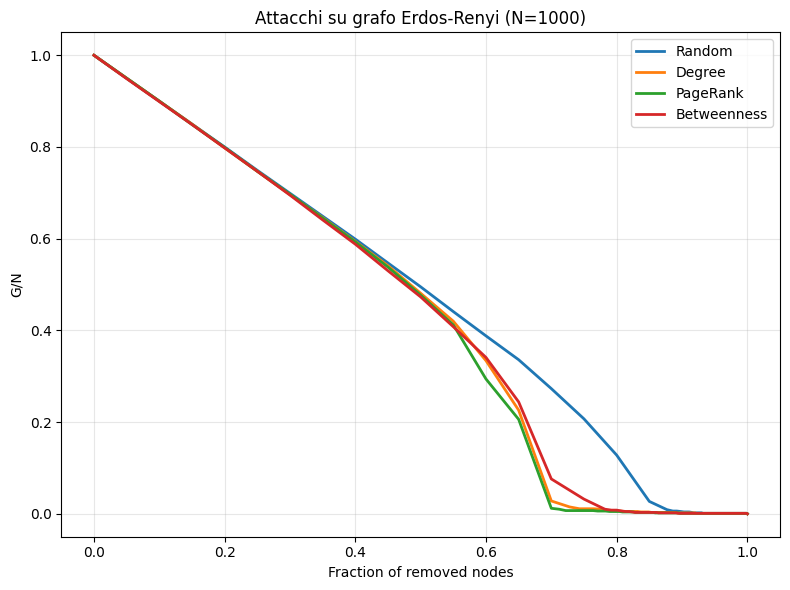

In [157]:
print("ATTACCHI GRAFO ERODOS-RENYI")
G_ER = nx.erdos_renyi_graph(1000, 0.01, seed=42)
results_ER = run_all_attacks(G_ER, batch_size=batch_ER, use_fraction=False)
plot_results(results_ER, "Attacchi su grafo Erdos-Renyi (N=1000)")

ATTACCHI GRAFO BARABASI-ALBERT
Simulazione dell'attacco: Random
COLLASSO: Random -> GC sotto il 50% dopo 500 nodi rimossi (50.0% della rete)
Simulazione dell'attacco: Degree
COLLASSO: Degree -> GC sotto il 50% dopo 375 nodi rimossi (37.5% della rete)
Simulazione dell'attacco: PageRank
COLLASSO: PageRank -> GC sotto il 50% dopo 350 nodi rimossi (35.0% della rete)
Simulazione dell'attacco: Betweenness
COLLASSO: Betweenness -> GC sotto il 50% dopo 375 nodi rimossi (37.5% della rete)


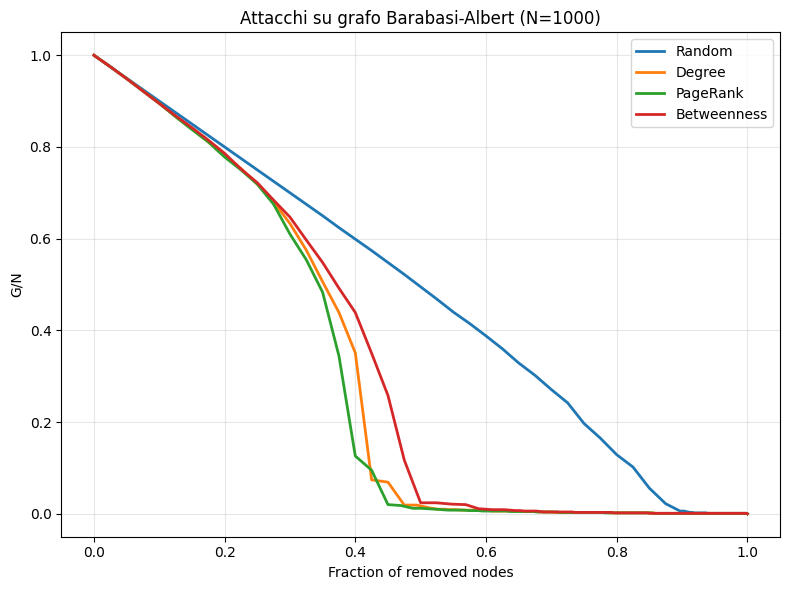

In [158]:
print("ATTACCHI GRAFO BARABASI-ALBERT")
G_BA = nx.barabasi_albert_graph(1000, 5, seed=42)
results_BA = run_all_attacks(G_BA, batch_size=batch_BA, use_fraction=False)
plot_results(results_BA, "Attacchi su grafo Barabasi-Albert (N=1000)")

## Use your graph

In [159]:
BASE_DIR = Path().resolve().parent
DATASET_PATH = BASE_DIR / "data" / "anime_filtered.csv"
filtered = pd.read_csv(DATASET_PATH)

In [160]:
def build_graph(ids, titles, genre_sets):
    """
    Costruisce il grafo Anime collegando due anime se condividono almeno 2 generi.
    Versione ottimizzata: usa un indice invertito per evitare il ciclo su 6.4M coppie.
    Risultato identico alla versione lenta, ma 10x più veloce.
    """

    G = nx.Graph()

    # Aggiungo i nodi
    for i, mid in enumerate(ids):
        G.add_node(mid, title=titles[i])

    # Indice invertito: genere -> lista di anime che lo hanno
    inverted = defaultdict(list)
    for idx, genres in enumerate(genre_sets):
        for g in genres:
            inverted[g].append(idx)

    # Contatore delle coppie: (i, j) -> numero di generi condivisi
    shared = defaultdict(int)

    # Per ogni genere, incrementa il contatore delle coppie che lo condividono
    for anime_list in inverted.values():
        anime_list = sorted(anime_list)
        for a in range(len(anime_list)):
            for b in range(a + 1, len(anime_list)):
                i = anime_list[a]
                j = anime_list[b]
                shared[(i, j)] += 1

    # Aggiungo archi solo per coppie con almeno 2 generi condivisi
    for (i, j), count in shared.items():
        if count >= 2:
            G.add_edge(ids[i], ids[j])

    return G

In [161]:
ids = filtered["mal_id"].tolist()
titles = filtered["title"].tolist()
genre_sets = [set(str(g).split("|")) for g in filtered["genres"]]

In [162]:
G_anime = build_graph(ids, titles, genre_sets)

n_nodes = G_anime.number_of_nodes()
n_edges = G_anime.number_of_edges()
density = nx.density(G_anime)
avg_degree = 2 * n_edges / n_nodes if n_nodes else 0
print(f"Grafo anime: N={n_nodes}, L={n_edges}, densita'={density:.4f}, "
      f"grado medio={avg_degree:.2f}")

Grafo anime: N=3579, L=780393, densita'=0.1219, grado medio=436.10


In [163]:
# Diagnostica frammentazione iniziale: un grafo costruito per similarita' di
# genere puo' essere NON connesso dall'inizio (tanti cluster isolati di
# anime con genere molto simile tra loro, ma poco Pesimili a tutto il resto).

n_components = nx.number_connected_components(G_anime)
GC_initial = largest_component(G_anime)
gc_fraction = GC_initial.number_of_nodes() / n_nodes if n_nodes else 0
print(f"Componenti connesse: {n_components} | "
      f"Componente gigante iniziale: {GC_initial.number_of_nodes()}/{n_nodes} "
      f"({gc_fraction:.1%} della rete)")

Componenti connesse: 728 | Componente gigante iniziale: 2838/3579 (79.3% della rete)


ATTACCHI GRAFO ANIME
Simulazione dell'attacco: Random
COLLASSO: Random -> GC sotto il 50% dopo 1046 nodi rimossi (29.2% della rete)
Simulazione dell'attacco: Degree
COLLASSO: Degree -> GC sotto il 50% dopo 938 nodi rimossi (26.2% della rete)
Simulazione dell'attacco: PageRank
COLLASSO: PageRank -> GC sotto il 50% dopo 1055 nodi rimossi (29.5% della rete)
Simulazione dell'attacco: Betweenness
COLLASSO: Betweenness -> GC sotto il 50% dopo 966 nodi rimossi (27.0% della rete)


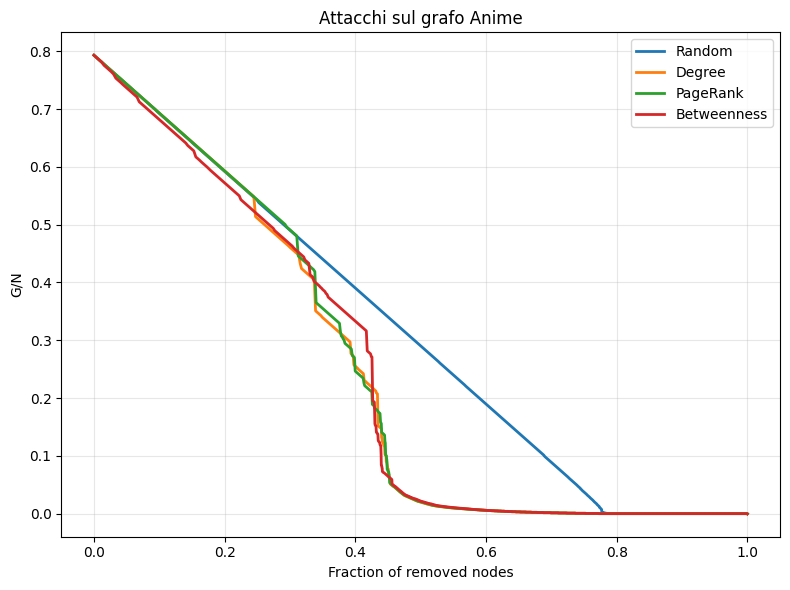

In [164]:
batch_ANIME = 0.005  # 0.5% per iterazione
print("ATTACCHI GRAFO ANIME")
results_anime = run_all_attacks(G_anime, batch_size=batch_ANIME, use_fraction=True, sample_size_bt=100)
plot_results(results_anime, "Attacchi sul grafo Anime")

In [165]:
# Discussione (punto 2 della consegna): quale strategia e' piu' dannosa?
print("Soglia (frazione di nodi rimossi) a cui G/N scende sotto 0.5 per ogni attacco:")
for name, (x, y) in results_anime.items():
    below = [xi for xi, yi in zip(x, y) if yi < 0.5]
    soglia = below[0] if below else None
    print(f"  {name}: {soglia}")

Soglia (frazione di nodi rimossi) a cui G/N scende sotto 0.5 per ogni attacco:
  Random: 0.29226040793517744
  Degree: 0.26208438111204246
  PageRank: 0.29477507683710535
  Betweenness: 0.269907795473596


## Building robustness

In [166]:
def compute_moments(G):
    """Primo e secondo momento della distribuzione del grado."""
    degrees = [d for _, d in G.degree()]
    k1 = sum(degrees) / len(degrees)
    k2 = sum(d * d for d in degrees) / len(degrees)
    return k1, k2

In [167]:
def critical_threshold(G):
    """Soglia critica teorica fc per guasti random (formula di Molloy-Reed)."""
    k1, k2 = compute_moments(G)
    if k2 <= k1:
        return 0
    return 1 - 1 / (k2 / k1 - 1)

In [168]:
def add_ring_degree(G, top_n=3, max_edges_per_node=200):
    """
    Aggiunge archi tra vicini dei nodi con grado maggiore.
    Limita il numero di nuovi archi per evitare esplosione combinatoria.
    """
    G_new = G.copy()
    degree = dict(G.degree())
    top_nodes = sorted(degree, key=degree.get, reverse=True)[:top_n]
    added = 0
    for node in top_nodes:
        neighbors = list(G_new.neighbors(node))
        count = 0
        for i in range(len(neighbors)):
            for j in range(i + 1, len(neighbors)):
                if count >= max_edges_per_node:
                    break
                u = neighbors[i]
                v = neighbors[j]
                if not G_new.has_edge(u, v):
                    G_new.add_edge(u, v)
                    added += 1
                    count += 1
            if count >= max_edges_per_node:
                break
    print(f"Ring Degree: aggiunti {added} archi")
    return G_new

In [169]:
def add_ring_betweenness(G, top_n=1, sample_size=500):
    """Aggiunge archi tra i vicini dei top-n nodi per betweenness stimata."""
    G_new = G.copy()
    sample_size = min(sample_size, G.number_of_nodes())
    bt = nx.betweenness_centrality(G, k=sample_size, seed=42)
    top_nodes = sorted(bt, key=bt.get, reverse=True)[:top_n]
    added = 0
    for node in top_nodes:
        neighbors = list(G_new.neighbors(node))
        for i in range(len(neighbors)):
            for j in range(i + 1, len(neighbors)):
                if not G_new.has_edge(neighbors[i], neighbors[j]):
                    G_new.add_edge(neighbors[i], neighbors[j])
                    added += 1
    print(f"Ring Betweenness: aggiunti {added} archi")
    return G_new

In [170]:
def add_edges_high_clustering(G, m=200):
    """
    Strategia di robustness basata sul clustering:
    seleziona i nodi con clustering più alto e aggiunge archi
    tra i loro vicini per aumentare la coesione locale.
    """
    G_new = G.copy()
    clustering = nx.clustering(G_new)

    # Ordina i nodi per clustering decrescente
    ordered = sorted(clustering, key=clustering.get, reverse=True)

    added = 0
    for u in ordered:
        if added >= m:
            break
        neighbors = list(G_new.neighbors(u))
        # Aggiungi archi tra coppie di vicini di u
        for i in range(len(neighbors)):
            for j in range(i + 1, len(neighbors)):
                if added >= m:
                    break
                v = neighbors[i]
                w = neighbors[j]
                if not G_new.has_edge(v, w):
                    G_new.add_edge(v, w)
                    added += 1
    print(f"High Clustering: aggiunti {added} archi")
    return G_new

In [171]:
results_robustness = []

In [172]:
k1, k2 = compute_moments(G_anime)
fc_original = critical_threshold(G_anime)
results_robustness.append(["Original", G_anime.number_of_nodes(), G_anime.number_of_edges(), k1, k2, fc_original])

In [173]:
G_deg = add_ring_degree(G_anime, top_n=3)
k1d, k2d = compute_moments(G_deg)
fc_deg = critical_threshold(G_deg)
results_robustness.append(["Ring Degree (top-3)", G_deg.number_of_nodes(), G_deg.number_of_edges(), k1d, k2d, fc_deg])

Ring Degree: aggiunti 600 archi


In [174]:
G_bt = add_ring_betweenness(G_anime, top_n=3, sample_size=200)
k1b, k2b = compute_moments(G_bt)
fc_bt = critical_threshold(G_bt)
results_robustness.append(["Ring Betweenness (top-3)", G_bt.number_of_nodes(), G_bt.number_of_edges(), k1b, k2b, fc_bt])

Ring Betweenness: aggiunti 1487668 archi


In [175]:
G_cl = add_edges_high_clustering(G_anime, m=200)
k1c, k2c = compute_moments(G_cl)
fc_cl = critical_threshold(G_cl)
results_robustness.append(["High Clustering (200 edges)", G_cl.number_of_nodes(), G_cl.number_of_edges(), k1c, k2c, fc_cl])

High Clustering: aggiunti 200 archi


In [176]:
df_results = pd.DataFrame(results_robustness, columns=["Graph", "N", "L", "1st moment", "2nd moment", "fc"])
print("=== Tabella soglie critiche teoriche ===")
print(df_results.to_string(index=False))

=== Tabella soglie critiche teoriche ===
                      Graph    N       L  1st moment   2nd moment       fc
                   Original 3579  780393  436.095557 3.516982e+05 0.998758
        Ring Degree (top-3) 3579  780993  436.430847 3.522868e+05 0.998760
   Ring Betweenness (top-3) 3579 2268061 1267.427214 2.577432e+06 0.999508
High Clustering (200 edges) 3579  780593  436.207320 3.518571e+05 0.998759
